# Heart Disease Prediction Project\n
## Optimized & Refactored Workflow\n
\n
**Changes made:**\n
- consolidated imports\n
- Fixed data leakage (Train/Test Split applied properly before training)\n
- Implemented Cross-Validation for robust model comparison\n
- Automated Hyperparameter Tuning for the best model\n
- Unified Feature Selection and Preprocessing

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Metrics & Saving
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, 
    roc_auc_score, RocCurveDisplay
)
import joblib

# Configuration
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
%matplotlib inline

In [3]:
# 2. Load Data
try:
    df = pd.read_csv("/heart.csv")
    print("Dataset Loaded Successfully.")
    print("Shape:", df.shape)
except FileNotFoundError:
    # Fallback for demonstration if file isn't found at root
    try:
        df = pd.read_csv("heart.csv")
        print("Dataset Loaded Successfully (local).")
    except:
        print("Error: Dataset not found. Please ensure 'heart.csv' is in the working directory.")

# Basic Inspection
display(df.head())
display(df.info())

Dataset Loaded Successfully (local).


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None

C:\Users\USER\AppData\Local\Temp\ipykernel_26708\3541740728.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, ax=ax[0], palette='coolwarm')


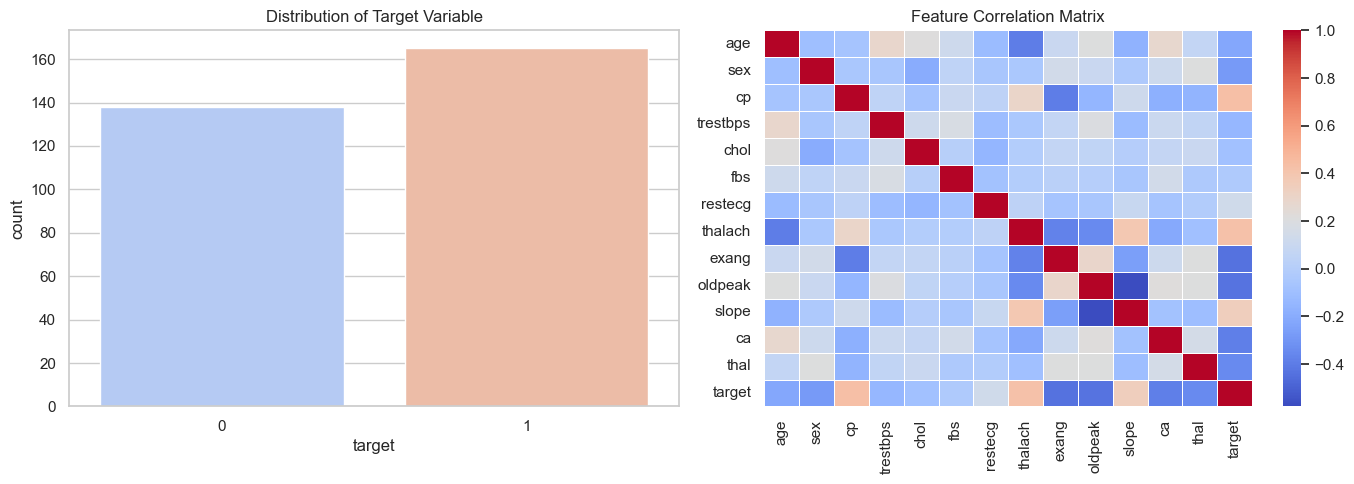

In [5]:
# 3. Exploratory Data Analysis (EDA)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Target Distribution
sns.countplot(x='target', data=df, ax=ax[0], palette='coolwarm')
ax[0].set_title("Distribution of Target Variable")

# Correlation Heatmap
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5, ax=ax[1])
ax[1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [6]:
# 4. Preprocessing & Data Splitting

# Separate Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Identify Numerical and Categorical columns automatically
categorical_cols = [col for col in X.columns if X[col].nunique() < 10]  # Simplistic heuristic for cat features
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numerical_cols)

# Define Preprocessing Pipelines

# Numerical: Impute missing -> Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing -> OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Train/Test Split (stratify to maintain target ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Train Shape: (242, 13), Test Shape: (61, 13)


In [7]:
# 5. Model Comparison (Cross-Validation)

# Define a set of models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "MLP Neural Net": MLPClassifier(max_iter=1000, random_state=42)
}

results = {}
print("Cross-Validation Scores (Accuracy):\n")

for name, model in models.items():
    # Create a full pipeline for each model to prevent leakage during CV
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('selector', SelectKBest(score_func=f_classif, k='all')), # Optional Feature Selection
                          ('classifier', model)])
    
    # 5-Fold Cross Validation
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    
    results[name] = cv_scores.mean()
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Select Best Model
best_model_name = max(results, key=results.get)
print(f"\nBest Baseline Model: {best_model_name} ({results[best_model_name]:.4f})")

Cross-Validation Scores (Accuracy):

Logistic Regression: 0.8474 (+/- 0.0697)
Random Forest: 0.8351 (+/- 0.1199)
Gradient Boosting: 0.8143 (+/- 0.0955)
SVM: 0.8226 (+/- 0.0736)
KNN: 0.8183 (+/- 0.0692)
MLP Neural Net: 0.8269 (+/- 0.1210)

Best Baseline Model: Logistic Regression (0.8474)


In [8]:
# 6. Hyperparameter Tuning (for Best Model)
# We will assume Random Forest or Gradient Boosting often perform well, 
# but let's tune the statistically best from previous step directly.

print(f"Tuning {best_model_name}...")

# Define parameter grids for common models
param_grids = {
    "Random Forest": {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    },
    "Gradient Boosting": {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5]
    },
    "Logistic Regression": {
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },
    "KNN": {
        'classifier__n_neighbors': [3, 5, 7, 9],
        'classifier__weights': ['uniform', 'distance']
    },
    "SVM": {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf']
    }
}

# Select appropriate grid, default to empty if model not in list (won't crash)
grid = param_grids.get(best_model_name, {})

final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('selector', SelectKBest(score_func=f_classif, k='all')),
                                 ('classifier', models[best_model_name])])

if grid:
    search = GridSearchCV(final_pipeline, grid, cv=5, scoring='accuracy', n_jobs=-1)
    search.fit(X_train, y_train)
    best_estimator = search.best_estimator_
    print("Best Params:", search.best_params_)
    print("Best CV Score:", search.best_score_)
else:
    print(f"No specific grid for {best_model_name}, using default parameters.")
    best_estimator = final_pipeline
    best_estimator.fit(X_train, y_train)

Tuning Logistic Regression...
Best Params: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}
Best CV Score: 0.8474489795918367


Final Test Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.79      0.85        28
           1       0.84      0.94      0.89        33

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.87        61
weighted avg       0.87      0.87      0.87        61



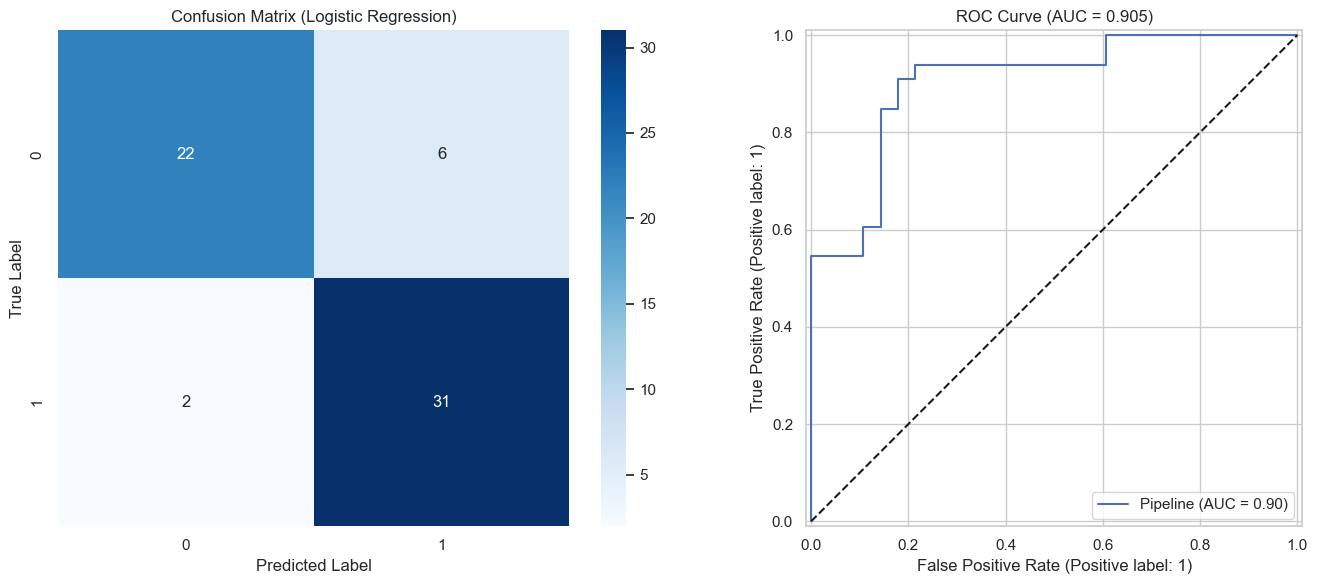

In [9]:
# 7. Final Evaluation on Test Set

y_pred = best_estimator.predict(X_test)
y_proba = best_estimator.predict_proba(X_test)[:, 1]

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualizations
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f"Confusion Matrix ({best_model_name})")
ax[0].set_ylabel("True Label")
ax[0].set_xlabel("Predicted Label")

# ROC Curve
RocCurveDisplay.from_estimator(best_estimator, X_test, y_test, ax=ax[1])
ax[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
ax[1].plot([0, 1], [0, 1], 'k--')

plt.tight_layout()
plt.show()

In [10]:
# 8. Feature Importance (if applicable)
if hasattr(best_estimator.named_steps['classifier'], 'feature_importances_'):
    importances = best_estimator.named_steps['classifier'].feature_importances_
    # Get feature names after preprocessing
    # Note: This can be tricky with pipelines, simplified for standard cases
    try:
        # Get feature names from transformers
        # The order in ColumnTransformer is [num, cat]
        num_names = numerical_cols
        cat_names = best_estimator.named_steps['preprocessor'].named_transformers_['cat']['encoder'].get_feature_names_out(categorical_cols)
        feature_names = np.r_[num_names, cat_names]
        
        # If SelectKBest selected a subset, we need to mask names (not implemented here for simplicity as we used k='all')
        
        feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
        plt.title("Top 10 Feature Importances")
        plt.show()
    except Exception as e:
        print("Could not extract feature names directly:", e)
else:
    print(f"Feature importance not available for {best_model_name} (linear models use coefficients).")

Feature importance not available for Logistic Regression (linear models use coefficients).


In [11]:
# 9. Save The Model
joblib.dump(best_estimator, "heart_disease_model.pkl")
print("Final model saved as 'heart_disease_model.pkl'")

Final model saved as 'heart_disease_model.pkl'
